In [1]:
# Install required libraries
!pip install datasets
!pip install tensorflow
!pip install opencv-python
!pip install scikit-learn
!pip install matplotlib
!pip install pillow

In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

Load Dataset

In [23]:
lfw = fetch_lfw_people(
    min_faces_per_person=50,
    resize=0.4
)
plfw

print("Dataset shape:", lfw.images.shape)
print("Number of people:", len(lfw.target_names))

Dataset shape: (1560, 50, 37)
Number of people: 12


Visualize Sample Images

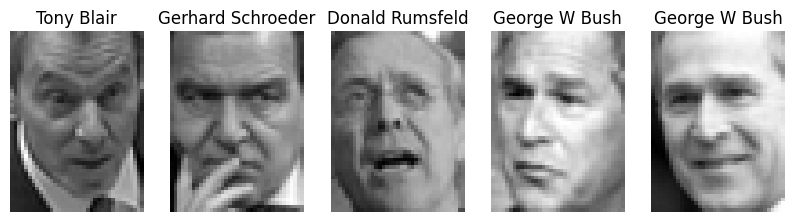

In [4]:
fig, axes = plt.subplots(1,5, figsize=(10,4))

for i, ax in enumerate(axes):
    ax.imshow(lfw.images[i], cmap="gray")
    ax.set_title(lfw.target_names[lfw.target[i]])
    ax.axis("off")

plt.show()

Prepare Data

In [5]:
X = lfw.images
y = lfw.target

Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

Resize Images

In [7]:
IMG_SIZE = 100

def resize_images(images):
    resized = []
    for img in images:
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        resized.append(img)
    return np.array(resized)

X_train = resize_images(X_train)
X_test = resize_images(X_test)

Normalize Images

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Reshape for CNN

In [9]:
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

Convert Labels to Categorical

In [10]:
num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

Build CNN Model

In [11]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(IMG_SIZE,IMG_SIZE,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(num_classes,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [12]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    validation_data=(X_test,y_test),
    batch_size=32
)

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.2919 - loss: 2.2109 - val_accuracy: 0.3590 - val_loss: 2.4474
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4727 - loss: 1.6429 - val_accuracy: 0.0769 - val_loss: 2.4683
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6636 - loss: 1.0220 - val_accuracy: 0.0410 - val_loss: 2.4727
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7773 - loss: 0.7034 - val_accuracy: 0.3590 - val_loss: 2.4674
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8398 - loss: 0.5227 - val_accuracy: 0.0410 - val_loss: 2.4750
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8730 - loss: 0.4095 - val_accuracy: 0.0410 - val_loss: 2.4768
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9196 - loss: 0.2798 - val_accuracy: 0.0410 - val_loss: 2.4775
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9204 - loss: 0.2250 - val_accuracy: 0.0410 -

Evaluate Model

In [14]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4942 - loss: 5.2900 
Test Accuracy: 0.48974359035491943


Save Model

In [15]:
os.makedirs("/content/models",exist_ok=True)

model.save("/content/models/face_cnn_model.h5")

print("Model saved successfully")

Model saved successfully


Plot Training Performance

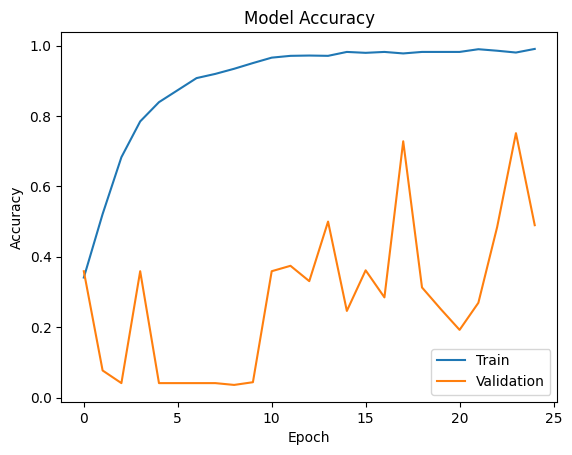

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

Pick Random Image From Dataset

In [19]:
persons = lfw.target_names

Predict Using CNN Model/Check If Prediction Is Correct

In [20]:
import random
import numpy as np
import matplotlib.pyplot as plt

def test_random_image():

    index = random.randint(0, len(X_test)-1)

    image = X_test[index]

    true_label = np.argmax(y_test[index])
    true_name = persons[true_label]

    input_img = image.reshape(1,100,100,1)

    prediction = model.predict(input_img, verbose=0)

    pred_label = np.argmax(prediction)

    pred_name = persons[pred_label]

    confidence = np.max(prediction)

    plt.imshow(image.reshape(100,100), cmap="gray")

    plt.title(f"True: {true_name}\nPredicted: {pred_name} ({confidence:.2f})")

    plt.axis("off")

    plt.show()

    if pred_label == true_label:
        print("Prediction Correct ✅")
    else:
        print("Prediction Wrong ❌")

Show Result

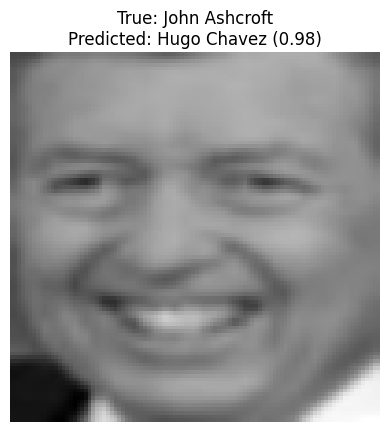

Prediction Wrong ❌


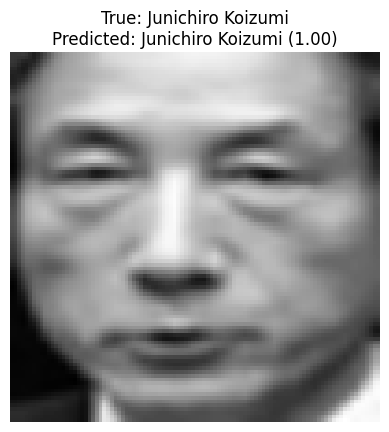

Prediction Correct ✅


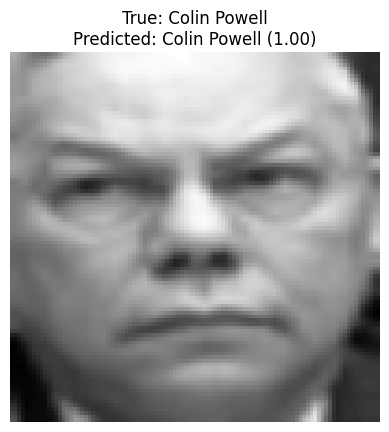

Prediction Correct ✅


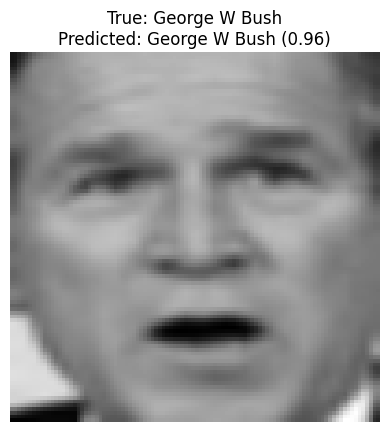

Prediction Correct ✅


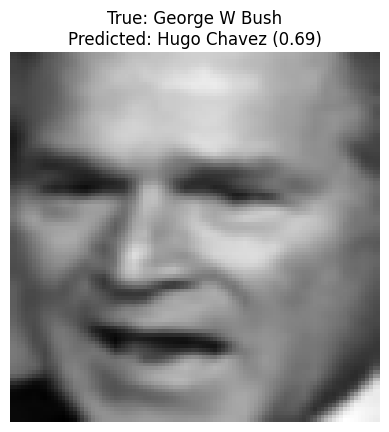

Prediction Wrong ❌


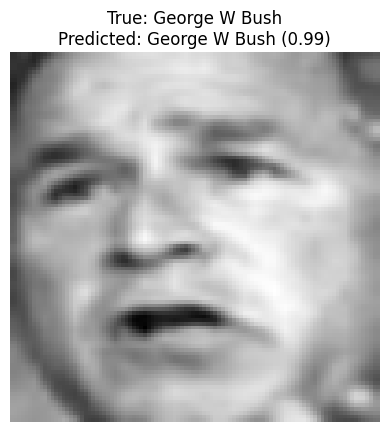

Prediction Correct ✅


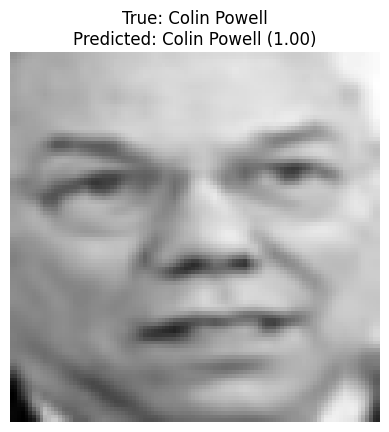

Prediction Correct ✅


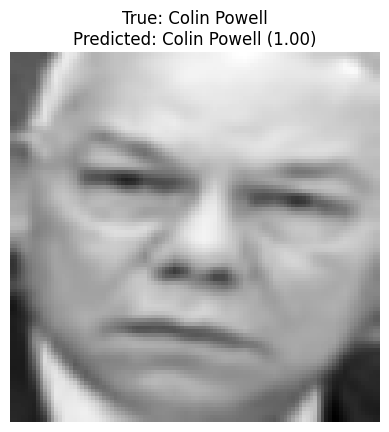

Prediction Correct ✅


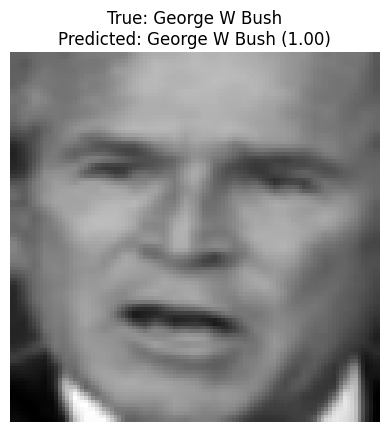

Prediction Correct ✅


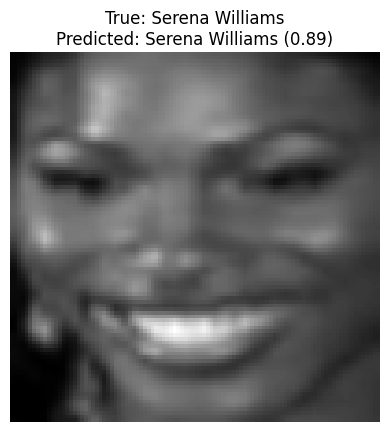

Prediction Correct ✅


In [21]:
for i in range(10):
    test_random_image()

In [22]:
correct = 0

for i in range(50):

    index = random.randint(0, len(X_test)-1)

    image = X_test[index]

    true_label = np.argmax(y_test[index])

    prediction = model.predict(image.reshape(1,100,100,1), verbose=0)

    pred_label = np.argmax(prediction)

    if pred_label == true_label:
        correct += 1

print("Random Test Accuracy:", correct/50)

Random Test Accuracy: 0.28
